#### Keras를 이용한 손글씨 인식 딥러닝
- TensorFlow로 작성된 프로그램은 sklearn보다 매우 어렵다.
- Keras는 테아노(Theano)와 TensoFlow를 Wrapping한 라이브러리



In [77]:
import pandas as pd

In [78]:
train = pd.read_csv("../Data/train_20k.csv", header=None)
train.head()


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [79]:
test = pd.read_csv("../Data/test_1k.csv", header=None)
test.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Data 불러오기

----

#### 결측치 확인

In [80]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 20001 entries, 0 to 20000
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 119.8 MB


In [81]:
# train의 결측치
train.isnull().sum().sum()

0

In [82]:
#test의 결측치
test.isnull().sum().sum()

0

#### Target Data의 비율 확인


In [83]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [84]:
import numpy as np

In [85]:
checkCount = np.unique(train[0], return_counts=True)[1] # 중복데이터 없이(unique), 중복을 없앤 값들이 원래 배열에 몇 개씩 있었는지 ... /[1] : 등장 횟수
np.min(checkCount) / np.max(checkCount) # 등장 횟수 중 최솟값 / 등장 횟수 중 최댓값

0.7786058746163963

> Data의 Target 비율이 최소 77%가 넘는다

#### train과 test를 Target과 Feature로 분리하고 정규화 하기

In [86]:
# train의 Data와 target
train_label = train.loc[:, train.columns == 0]
train_data = train.loc[:, train.columns != 0] / 255.0

# test의 Data와 target
test_label = test.loc[:, test.columns == 0]
test_data = test.loc[:, test.columns != 0] / 255.0



In [87]:
train.columns

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       775, 776, 777, 778, 779, 780, 781, 782, 783, 784],
      dtype='int64', length=785)

In [88]:
test.columns

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       775, 776, 777, 778, 779, 780, 781, 782, 783, 784],
      dtype='int64', length=785)

#### Deep Learning Model 만들기

In [89]:
from tensorflow import keras
from tensorflow.keras.layers import Input

In [90]:
# 모델 생성하기

model = keras.Sequential()
model.add(Input(shape=(784,))) # 입력층
model.add(keras.layers.Dense(100, activation='relu')) # 은닉층은 여러개가 가능
model.add(keras.layers.Dense(10, activation='softmax')) # 출력층

# 손실함수
model.compile(
   optimizer = 'adam',
   loss = 'sparse_categorical_crossentropy',
   metrics = ['accuracy']
)

# 데이터 훈력하기
model.fit(
   np.array(train_data),
   np.array(train_label),
   epochs = 10
)

Epoch 1/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8814 - loss: 0.4257
Epoch 2/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9413 - loss: 0.2027
Epoch 3/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9597 - loss: 0.1415
Epoch 4/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9687 - loss: 0.1085
Epoch 5/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9765 - loss: 0.0836
Epoch 6/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9803 - loss: 0.0677
Epoch 7/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9856 - loss: 0.0516
Epoch 8/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9888 - loss: 0.0415
Epoch 9/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9916 - loss: 0.0318
Epoch 10/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9948 - loss: 0.0250


In [91]:
# 테스트 데이터로 평가하기
score = model.evaluate(test_data,test_label)
print("loss =", score[0])
print("accuracy", score[1])


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9700 - loss: 0.0991
loss = 0.0990750789642334
accuracy 0.9700299501419067


#### test_data로 predict 해보기

In [92]:
pred = model.predict(test_data)
print("test_label : ", test_label[:10])
print("pred", np.argmax(pred[:10], axis=1)) # argmax: 예측값 중 최대값의 index

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
test_label :     0
0  7
1  2
2  1
3  0
4  4
5  1
6  4
7  9
8  5
9  9
pred [7 2 1 0 4 1 4 9 6 9]


In [93]:
# test_data의 0번 예측값 확인
print("정딥 :", test_label.loc[0])
print("예측값 :", np.argmax(pred[0]))

정딥 : 0    7
Name: 0, dtype: int64
예측값 : 7


#### 사용 : Image 만들기

In [94]:
from PIL import Image

# train_data 크기
train.shape

In [95]:
# 0번의 정답을 제외한 데이터
train1 = train.loc[:, train.columns != 0]
train1.shape

(20001, 784)

In [96]:
# train1의 데이터의 50번째로 이미지 만들기
abc = np.array(train1.iloc[50]).reshape(28,28)
abc.shape

(28, 28)

In [97]:
# Image 만들기
image = Image.fromarray((abc).astype(np.uint8))
image

In [98]:
# Image 저장하기
image.save("../Data/mnist_test_3.jpg", "JPEG")

----
#### 이미지를 불러서 predict 해보기

In [99]:
# Image 불러오기
img = Image.open("../Data/mnist_test_3.jpg")
img

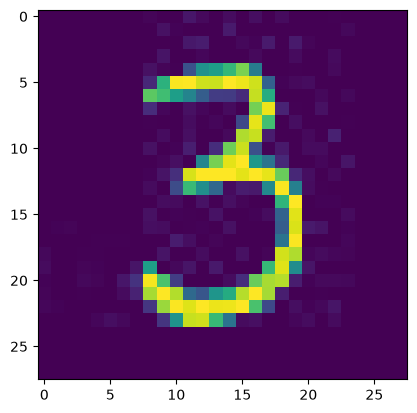

In [100]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.show()

In [101]:
# Image를 numpy 배열로 변경하고 정규화 하기
imgArray = np.array(img) / 55.0
imgArray.shape

(28, 28)

In [102]:
# image를 1차원 배열로 변경
imgArray2 = imgArray.reshape(-1)
imgArray2.shape


(784,)

In [103]:
imgArray2

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.05454545, 0.        ,
       0.        , 0.27272727, 0.10909091, 0.        , 0.14545455,
       0.        , 0.16363636, 0.        , 0.12727273, 0.        ,
       0.        , 0.        , 0.01818182, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.2       , 0.03636364, 0.        ,
       0.        , 0.        , 0.32727273, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.09090909, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.29090909, 0.34545455, 0.        ,
       0.        , 0.09090909, 0.03636364, 0.32727273, 0.     

In [104]:
# 

imgArray3 = imgArray2.tolist()
imgArray3

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.05454545454545454,
 0.0,
 0.0,
 0.2727272727272727,
 0.10909090909090909,
 0.0,
 0.14545454545454545,
 0.0,
 0.16363636363636364,
 0.0,
 0.12727272727272726,
 0.0,
 0.0,
 0.0,
 0.01818181818181818,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.2,
 0.03636363636363636,
 0.0,
 0.0,
 0.0,
 0.32727272727272727,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.09090909090909091,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.2909090909090909,
 0.34545454545454546,
 0.0,
 0.0,
 0.09090909090909091,
 0.03636363636363636,
 0.32727272727272727,
 0.0,
 0.32727272727272727,
 0.05454545454545454,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.23636363636363636,
 0.0,
 0.0,
 0.07272727272727272,
 0.0,
 0.0,
 0.0,
 0.10909090909090909,
 0.0,
 0.0,
 0.12727272727272726,
 0.0,
 0.0,
 0.12727272727272726,
 0.0,
 0

In [105]:
dfArray = pd.DataFrame(imgArray3)
dfArray = dfArray.T
dfArray

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.054545,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [106]:
print("예측값 :", np.argmax(model.predict(dfArray), axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
예측값 : [3]


In [107]:
model.predict(dfArray)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[1.4259758e-34, 1.0685173e-24, 7.8788124e-25, 1.0000000e+00,
        0.0000000e+00, 1.5719091e-20, 0.0000000e+00, 5.2022344e-33,
        6.7664846e-26, 1.1356592e-21]], dtype=float32)

----
#### train1의 데이터를 150번째로 이미지 만들기

In [108]:
ABC = np.array(train1.iloc[150]).reshape(28,28)
ABC.shape

(28, 28)

In [109]:
# Image 만들기
image = Image.fromarray((ABC).astype(np.uint8))
image

In [110]:
# Image 저장하기
image.save("../Data/mnist_test_4.jpg", "JPEG")

In [111]:
# Image 불러오기
img = Image.open("../Data/mnist_test_4.jpg")
img

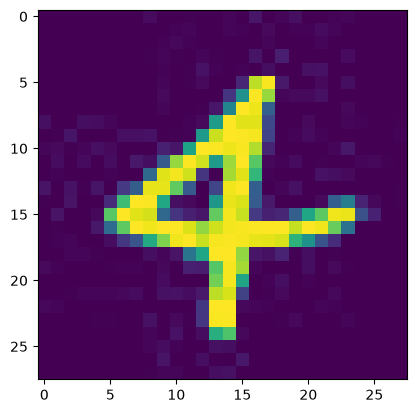

In [112]:
plt.imshow(img)
plt.show()

In [113]:
# Image를 numpy 배열로 변경하고 정규화 하기
imgArray = np.array(img) / 55.0
imgArray.shape

(28, 28)

In [114]:
# image를 1차원 배열로 변경
imgArray2 = imgArray.reshape(-1)
imgArray2.shape


(784,)

In [115]:
imgArray3 = imgArray2.tolist()
imgArray3

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.12727272727272726,
 0.0,
 0.0,
 0.01818181818181818,
 0.0,
 0.0,
 0.05454545454545454,
 0.0,
 0.2727272727272727,
 0.0,
 0.07272727272727272,
 0.18181818181818182,
 0.0,
 0.0,
 0.03636363636363636,
 0.07272727272727272,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.03636363636363636,
 0.07272727272727272,
 0.0,
 0.0,
 0.07272727272727272,
 0.03636363636363636,
 0.0,
 0.10909090909090909,
 0.0,
 0.03636363636363636,
 0.03636363636363636,
 0.12727272727272726,
 0.07272727272727272,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.03636363636363636,
 0.09090909090909091,
 0.03636363636363636,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.07272727272727272,
 0.0,
 0.0,
 0.0,
 0.07272727272727272,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.01818181818181818,
 0.07272727272727272,
 0.01818181818181818,
 0.0,
 0.05454545454545454,
 0.

In [116]:
dfArray = pd.DataFrame(imgArray3)
dfArray = dfArray.T
dfArray

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.127273,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [117]:
print("예측값2 :", np.argmax(model.predict(dfArray), axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
예측값2 : [4]


In [118]:
model.predict(dfArray)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


array([[2.3538400e-16, 1.1071862e-15, 2.8025939e-09, 8.5307656e-14,
        1.0000000e+00, 1.8831141e-30, 4.4712458e-08, 7.9996773e-11,
        1.1045538e-30, 3.5392029e-21]], dtype=float32)

----
### 딥러닝 구성
##### 딥러닝 신경망의 흐름
##### 1. 입력층(INput Layer)
- 입력 데이터를 받는 중입니다. 데이터는 보통 숫자로 변환된 성태로 들어옵니다.
- 입력층은 데이터의 특징이나 변수를 신경망에 전달합니다.

##### 2. 은닉층(Hidden Layer)
- 입력층에서 받은 데이터를 처리하는 중간 단계 입니다. 하나 이상의 은닉층이 있을 수 있습니다.
- 각 은닉층에서는 활성화 함수(Activation Function)가 적용됩니다. 각 노드에서 계산된 값을 비선형적으로 변환하여(확률) 다음 중으로 전달합니다.
- 대표적인 활성화 함수로는 Relu, Sigmoid, Adam, Tanh 등이 있습니다.

##### 3. 출력층(Output Layer)
- 은닉층에서 전달된 데잍터를 최종적으로 처리하여 결과를 내는 층입니다.
- 분류 문제라면 Softmax나 Sigmoid 가튼 활성화 함수가 사용되어 예측 확률을 계산합니다.

##### 4. 손실 함수(Loss Function)
- 출력층에서 나온 결과와 실제 값(정답)을 비교하여 오류를 계산합니다. 손실함수는 예측이 올마나 잘못 되었는지를 평가합니다.
- 대표적인 손실함수로는 회귀 문제에 사용되는 MAE, RMSE와 분류 문제에 사용되는 Cross Entropy가 있습니다.

##### 5. 최적화 함수(Optimization Function)
- 손실함수에서 계산된 오류를 바탕으로 네트워크의 가중치를 업데이트 합니다. 이를 통해 모델이 더 좋은 예측을 할 수 있도록 학습이 진행 됩니다.
- 대표적인 최적화 함수로는 확률적 경사하강법, Adam이 있습니다.
- 최적화 함수는 역전파(BackPropagation)과정에서 가중치와 편향을 조절하는 역할을 합니다.

--
> 이 과정이 여러번 반복되면서 신경망은 학습을 통해 점점 더 좋은 결과를 내놓는다.
